# Phát hiện URL độc hại bằng mô hình LightGBM

**Bài toán:** Phân loại nhị phân URL *độc hại* (lừa đảo, phishing) và URL *an toàn*.

**Phương pháp:** Kết hợp đặc trưng ký tự TF-IDF (char n-gram) với 14 đặc trưng số trích xuất từ cấu trúc URL, đưa vào bộ phân loại **LightGBM** (Gradient Boosting Decision Tree). Siêu tham số được tối ưu bằng **GridSearchCV** với kiểm định chéo phân tầng 5-fold; ngưỡng quyết định được tối ưu theo F1.

---

**Tóm tắt (Abstract).** Nghiên cứu này xây dựng và đánh giá một mô hình phát hiện URL độc hại dựa trên LightGBM. Trên tập dữ liệu gồm hơn 9.000 URL, chúng tôi (i) phân tích thống kê 14 đặc trưng cấu trúc URL và kiểm định mức độ phân biệt của chúng bằng kiểm định Mann–Whitney U; (ii) huấn luyện mô hình LightGBM với đầu vào lai (TF-IDF ký tự + đặc trưng số) và so sánh với mô hình cơ sở Logistic Regression; (iii) áp dụng giao thức đánh giá **chia dữ liệu theo tên miền đăng ký** (group split) để loại bỏ rò rỉ dữ liệu, kèm thí nghiệm định lượng cho thấy chia ngẫu nhiên thổi phồng kết quả một cách đáng kể; (iv) đánh giá bằng ROC-AUC, PR-AUC, F1 và tối ưu ngưỡng quyết định; (v) diễn giải mô hình bằng độ quan trọng đặc trưng và giá trị SHAP. Kết quả cho thấy LightGBM vượt trội mô hình cơ sở một cách có ý nghĩa thống kê trên các tên miền hoàn toàn mới — điều kiện sát với thực tế triển khai, nơi tên miền lừa đảo luôn được đăng ký mới.

## 1. Giới thiệu

URL độc hại (phishing, lừa đảo trúng thưởng, phát tán mã độc) là một trong những vector tấn công phổ biến nhất trên các nền tảng nhắn tin. Việc phát hiện theo danh sách đen (blacklist) có độ trễ lớn vì tên miền lừa đảo có vòng đời rất ngắn; do đó cần một mô hình học máy có khả năng **tổng quát hoá từ đặc điểm cấu trúc** của URL.

**Đóng góp chính của báo cáo:**

1. Bộ đặc trưng lai gồm **TF-IDF ký tự (n-gram 3–5)** nắm bắt mẫu chuỗi bất thường, và **14 đặc trưng số** mô tả cấu trúc URL (độ dài, entropy, mật độ ký tự đặc biệt, TLD đáng ngờ, ...).
2. Kiểm định thống kê (Mann–Whitney U) chứng minh khả năng phân biệt của từng đặc trưng.
3. **Giao thức đánh giá chống rò rỉ dữ liệu:** cả holdout lẫn các fold kiểm định chéo đều được chia **theo tên miền đăng ký** (GroupShuffleSplit / StratifiedGroupKFold) — không tên miền nào xuất hiện đồng thời ở hai phía của bất kỳ phép chia nào; kèm thí nghiệm đối chứng định lượng mức thổi phồng của cách chia ngẫu nhiên.
4. So sánh với baseline bằng paired t-test, tối ưu ngưỡng quyết định, đường cong học tập.
5. Diễn giải mô hình bằng gain importance và SHAP (SHapley Additive exPlanations).

**Lý do chọn LightGBM:** thuật toán Gradient Boosting Decision Tree với chiến lược phát triển cây *leaf-wise* và kỹ thuật histogram binning, cho tốc độ huấn luyện nhanh và độ chính xác cao trên dữ liệu dạng bảng, xử lý tốt đặc trưng thưa (sparse) từ TF-IDF — phù hợp với yêu cầu suy luận thời gian thực của hệ thống kiểm duyệt.

In [1]:
import sys, time, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, classification_report,
                             confusion_matrix, f1_score, precision_recall_curve,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, GroupShuffleSplit,
                                     StratifiedGroupKFold, cross_val_score,
                                     learning_curve, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier

from ai.feature_extractor import extract_features

warnings.filterwarnings("ignore", message="X does not have valid feature names")
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Tahoma", "Arial", "DejaVu Sans"],
    "axes.unicode_minus": False,
})
C_MAL, C_BEN = "#d62728", "#2ca02c"   # đỏ = độc hại, xanh = an toàn

import lightgbm, sklearn
print("Python     :", sys.version.split()[0])
print("LightGBM   :", lightgbm.__version__)
print("scikit-learn:", sklearn.__version__)

Python     : 3.12.5
LightGBM   : 4.6.0
scikit-learn: 1.7.2


## 2. Dữ liệu

Tập dữ liệu `data/urls.csv` gồm các URL thu thập thực tế, gán nhãn thủ công:

| Nhãn | Ý nghĩa |
|------|---------|
| `0`  | **Độc hại** (phishing, lừa đảo, trang giả mạo) |
| `1`  | **An toàn** (trang hợp pháp) |

Các bản ghi trùng lặp theo URL được loại bỏ để tránh rò rỉ dữ liệu (data leakage) giữa tập huấn luyện và tập kiểm tra.

In [2]:
DATA_PATH = Path.cwd() / "data" / "urls.csv"
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip().lower() for c in df.columns]
df = df.rename(columns={"labels": "label", "urls": "url"})

n_raw = len(df)
df = df.drop_duplicates(subset="url").reset_index(drop=True)
print(f"Số mẫu gốc: {n_raw:,}  |  Sau khi khử trùng lặp: {len(df):,}")
df.head()

Số mẫu gốc: 9,171  |  Sau khi khử trùng lặp: 9,136


,url,label
0,https://courses.ut.edu.vn/mod/quiz/attempt.php...,1
1,https://bruno.taweb.net.br/asd,0
2,https://claim-fantom-72h.com/FS24fvV243AQQ,0
3,https://m.ani4u.org/xem-anime/strawberry-panic...,1
4,https://ilovedevelopers.com/data/9NF28238VF7/i...,0


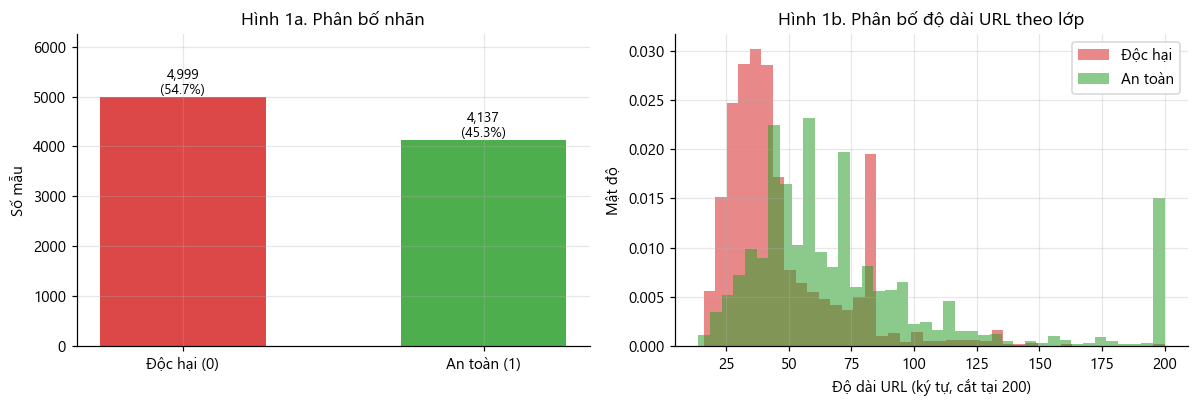

Tỷ lệ mất cân bằng lớp: 0.828 (gần cân bằng — vẫn dùng class_weight='balanced' để an toàn)


In [3]:
counts = df["label"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

bars = axes[0].bar(["Độc hại (0)", "An toàn (1)"], counts.values,
                   color=[C_MAL, C_BEN], width=0.55, alpha=0.85)
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x() + b.get_width()/2, v, f"{v:,}\n({v/len(df):.1%})",
                 ha="center", va="bottom", fontsize=9)
axes[0].set_ylim(0, counts.max() * 1.25)
axes[0].set_ylabel("Số mẫu")
axes[0].set_title("Hình 1a. Phân bố nhãn")

url_len = df["url"].str.len()
for lbl, name, color in [(0, "Độc hại", C_MAL), (1, "An toàn", C_BEN)]:
    axes[1].hist(url_len[df.label == lbl].clip(upper=200), bins=40,
                 alpha=0.55, label=name, color=color, density=True)
axes[1].set_xlabel("Độ dài URL (ký tự, cắt tại 200)")
axes[1].set_ylabel("Mật độ")
axes[1].set_title("Hình 1b. Phân bố độ dài URL theo lớp")
axes[1].legend()
plt.tight_layout()
plt.show()

ratio = counts.min() / counts.max()
print(f"Tỷ lệ mất cân bằng lớp: {ratio:.3f} (gần cân bằng — vẫn dùng class_weight='balanced' để an toàn)")

### 2.1. Cấu trúc nhóm theo tên miền — nguy cơ rò rỉ dữ liệu

Một quan sát then chốt: nhiều URL trong tập dữ liệu **chia sẻ cùng tên miền đăng ký**. Nếu chia train/test ngẫu nhiên theo từng URL, cùng một tên miền sẽ xuất hiện ở cả hai phía; khi đó biểu diễn TF-IDF ký tự chỉ cần "ghi nhớ" chuỗi tên miền là dự đoán đúng — mô hình được chấm điểm trên thông tin nó đã thuộc lòng chứ không phải trên khả năng tổng quát hoá. Đây là một dạng **rò rỉ dữ liệu (data leakage)** phổ biến trong các nghiên cứu phát hiện URL độc hại.

Trong thực tế triển khai, tên miền lừa đảo gần như luôn **mới đăng ký** — hệ thống phải phán đoán trên tên miền chưa từng thấy. Vì vậy, toàn bộ thí nghiệm trong báo cáo này dùng **chia theo nhóm tên miền**: mỗi tên miền đăng ký chỉ thuộc về đúng một phía của mọi phép chia (mục 4.3), và mục 5.3 sẽ định lượng mức thổi phồng nếu dùng cách chia ngẫu nhiên.

In [4]:
from urllib.parse import urlparse

def registered_domain(url: str) -> str:
    """Tên miền đăng ký xấp xỉ = hai nhãn cuối của hostname."""
    try:
        host = (urlparse(str(url).strip()).hostname or "").lower()
    except Exception:
        host = ""
    parts = host.split(".")
    return ".".join(parts[-2:]) if len(parts) >= 2 else (host or "unknown")

df["domain"] = df["url"].map(registered_domain)
n_dom = df["domain"].nunique()
print(f"Số tên miền đăng ký duy nhất: {n_dom:,}  →  trung bình {len(df)/n_dom:.2f} URL / tên miền")

top_dom = (df.groupby("domain")
             .agg(so_URL=("url", "size"),
                  ty_le_doc_hai=("label", lambda s: (s == 0).mean()))
             .sort_values("so_URL", ascending=False).head(10))
top_dom.columns = ["Số URL", "Tỷ lệ độc hại"]
print("\n10 tên miền có nhiều URL nhất:")
top_dom.round(3)

Số tên miền đăng ký duy nhất: 2,164  →  trung bình 4.22 URL / tên miền

10 tên miền có nhiều URL nhất:


,Số URL,Tỷ lệ độc hại
domain,,
google.com,1264,0.360
youtube.com,426,0.000
pages.dev,305,0.997
edu.vn,297,0.000
chatgpt.com,231,0.000
weebly.com,217,1.000
animevietsub.show,168,0.000
ppy.sh,129,0.000
kaggle.com,122,0.000


## 3. Trích xuất đặc trưng

Mỗi URL được biểu diễn bằng **14 đặc trưng số** (bảng dưới) kết hợp với **biểu diễn TF-IDF ký tự** của toàn chuỗi URL:

| # | Đặc trưng | Mô tả | Cơ sở lý thuyết |
|---|-----------|-------|-----------------|
| 1 | `url_length` | Độ dài toàn URL | URL phishing thường dài bất thường để che giấu tên miền thật |
| 2 | `path_length` | Độ dài phần path | — |
| 3 | `query_length` | Độ dài query string | Query dài chứa token/payload đáng ngờ |
| 4 | `num_params` | Số tham số query | — |
| 5 | `has_https` | Có dùng HTTPS | Trang hợp pháp gần như luôn dùng HTTPS |
| 6 | `domain_length` | Độ dài hostname | Tên miền giả mạo thường dài (vd. `paypal-secure-login.xyz`) |
| 7 | `subdomain_depth` | Số cấp subdomain | Lạm dụng subdomain để giả mạo thương hiệu |
| 8 | `tld_suspicious` | TLD thuộc nhóm rủi ro cao (`.xyz`, `.top`, `.tk`, ...) | TLD giá rẻ bị lạm dụng nhiều trong phishing |
| 9 | `num_digits` | Số chữ số trong URL (đã decode) | — |
| 10 | `num_special` | Số ký tự đặc biệt `-_@%=~!` | Ký tự `@`, `-` dùng trong kỹ thuật đánh lừa thị giác |
| 11 | `num_url_encoded` | Số chuỗi mã hoá `%XX` | Dấu hiệu obfuscation |
| 12 | `entropy` | Entropy Shannon của tên miền | Tên miền sinh tự động (DGA) có entropy cao |
| 13 | `path_depth` | Số cấp thư mục trong path | — |
| 14 | `is_ip_address` | Host là địa chỉ IP | Dùng IP trực tiếp để né kiểm tra tên miền |

Trong đó entropy Shannon của chuỗi $s$ được tính:

$$H(s) = -\sum_{c \in s} p(c)\, \log_2 p(c)$$

với $p(c)$ là tần suất tương đối của ký tự $c$.

In [5]:
t0 = time.time()
rows, labels = [], []
for url, label in zip(df["url"], df["label"]):
    u = str(url).strip()
    try:
        feats = extract_features(u)
    except ValueError:
        continue
    feats["url"] = u
    rows.append(feats)
    labels.append(int(label))

X = pd.DataFrame(rows)
y = pd.Series(labels, name="label")
NUMERIC = [c for c in X.columns if c != "url"]

print(f"Trích xuất {len(X):,} mẫu × {len(NUMERIC)} đặc trưng số trong {time.time()-t0:.1f}s")
X[NUMERIC].describe().T.round(3)

Trích xuất 9,136 mẫu × 14 đặc trưng số trong 0.4s


,count,mean,std,min,25%,50%,75%,max
url_length,9136.0,64.542,67.604,14.000,35.000,48.000,73.000,1433.000
path_length,9136.0,19.846,23.027,0.000,1.000,10.000,32.000,201.000
query_length,9136.0,16.172,64.915,0.000,0.000,0.000,0.000,1382.000
num_params,9136.0,0.516,1.453,0.000,0.000,0.000,0.000,17.000
has_https,9136.0,0.962,0.192,0.000,1.000,1.000,1.000,1.000
domain_length,9136.0,19.120,9.098,4.000,14.000,17.000,24.000,101.000
subdomain_depth,9136.0,0.790,0.683,0.000,0.000,1.000,1.000,6.000
tld_suspicious,9136.0,0.075,0.264,0.000,0.000,0.000,0.000,1.000
num_digits,9136.0,6.595,12.692,0.000,0.000,2.000,8.000,228.000
num_special,9136.0,2.304,3.901,0.000,0.000,1.000,3.000,54.000


### 3.1. Kiểm định khả năng phân biệt của từng đặc trưng

Để chứng minh các đặc trưng thực sự mang thông tin phân lớp, ta dùng **kiểm định Mann–Whitney U** (phi tham số, không giả định phân phối chuẩn) so sánh phân phối của mỗi đặc trưng giữa hai lớp. Cột *effect size* $r$ (rank-biserial, $|r| \in [0,1]$) đo **độ lớn** của khác biệt — p-value nhỏ kết hợp $|r|$ lớn nghĩa là đặc trưng phân biệt tốt.

In [6]:
rows_test = []
for f in NUMERIC:
    a = X.loc[y.values == 0, f]   # độc hại
    b = X.loc[y.values == 1, f]   # an toàn
    u_stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    r = 1 - 2 * u_stat / (len(a) * len(b))   # rank-biserial effect size
    rows_test.append({
        "Đặc trưng": f,
        "Trung bình (độc hại)": a.mean(),
        "Trung bình (an toàn)": b.mean(),
        "p-value": p,
        "Effect size |r|": abs(r),
    })

stat_df = (pd.DataFrame(rows_test)
             .sort_values("Effect size |r|", ascending=False)
             .reset_index(drop=True))
n_sig = (stat_df["p-value"] < 0.001).sum()
print(f"{n_sig}/{len(NUMERIC)} đặc trưng khác biệt có ý nghĩa thống kê ở mức p < 0.001")
stat_df.style.format({
    "Trung bình (độc hại)": "{:.3f}", "Trung bình (an toàn)": "{:.3f}",
    "p-value": "{:.2e}", "Effect size |r|": "{:.3f}",
}).background_gradient(subset=["Effect size |r|"], cmap="Reds")

11/14 đặc trưng khác biệt có ý nghĩa thống kê ở mức p < 0.001


,Đặc trưng,Trung bình (độc hại),Trung bình (an toàn),p-value,Effect size |r|
0,entropy,3.565,3.190,0.00e+00,0.522
1,domain_length,22.616,14.897,0.00e+00,0.514
2,path_length,13.661,27.320,0.00e+00,0.502
3,url_length,47.628,84.980,0.00e+00,0.459
4,path_depth,1.573,2.293,1.09e-255,0.392
5,num_digits,3.825,9.943,3.93e-167,0.324
6,num_special,1.260,3.565,2.92e-164,0.322
7,num_params,0.112,1.003,3.10e-288,0.312
8,query_length,2.993,32.096,3.62e-262,0.301
9,tld_suspicious,0.113,0.030,4.24e-50,0.083


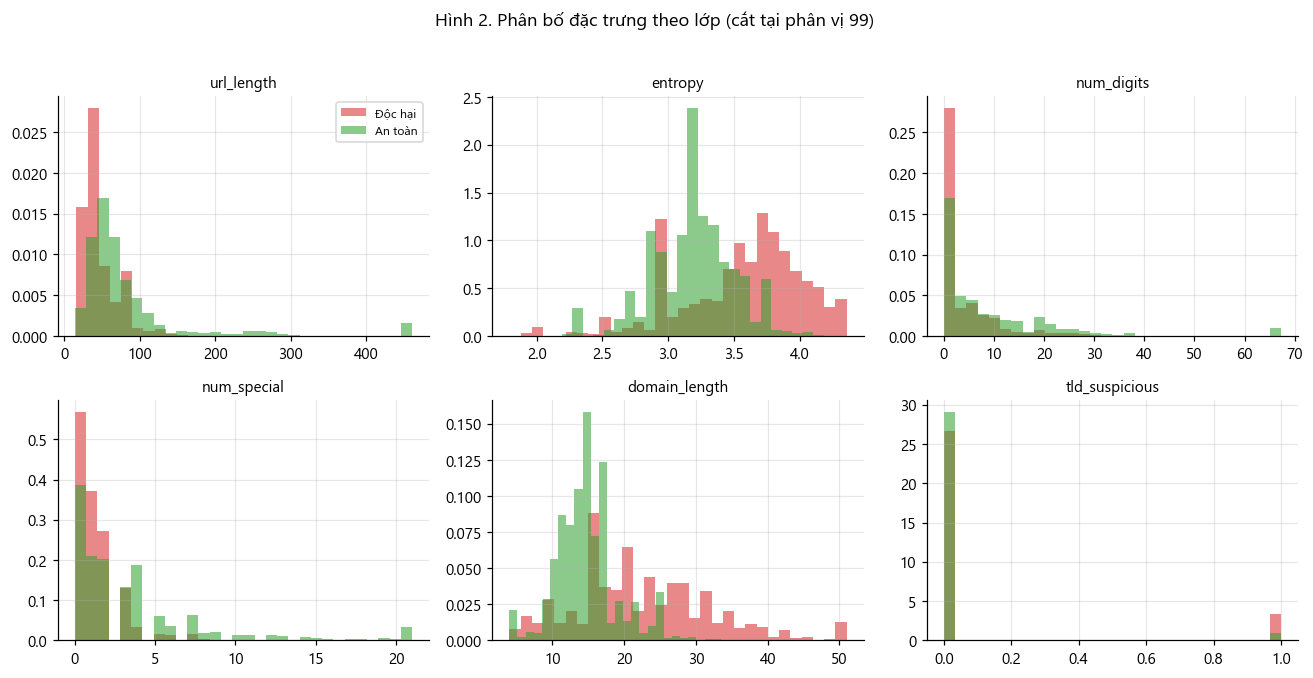

In [7]:
SHOW = ["url_length", "entropy", "num_digits", "num_special", "domain_length", "tld_suspicious"]
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, f in zip(axes.ravel(), SHOW):
    hi = np.percentile(X[f], 99)
    for lbl, name, color in [(0, "Độc hại", C_MAL), (1, "An toàn", C_BEN)]:
        vals = X.loc[y.values == lbl, f].clip(upper=hi)
        ax.hist(vals, bins=30, alpha=0.55, density=True, label=name, color=color)
    ax.set_title(f, fontsize=10)
axes[0, 0].legend(fontsize=8)
fig.suptitle("Hình 2. Phân bố đặc trưng theo lớp (cắt tại phân vị 99)", y=1.02)
plt.tight_layout()
plt.show()

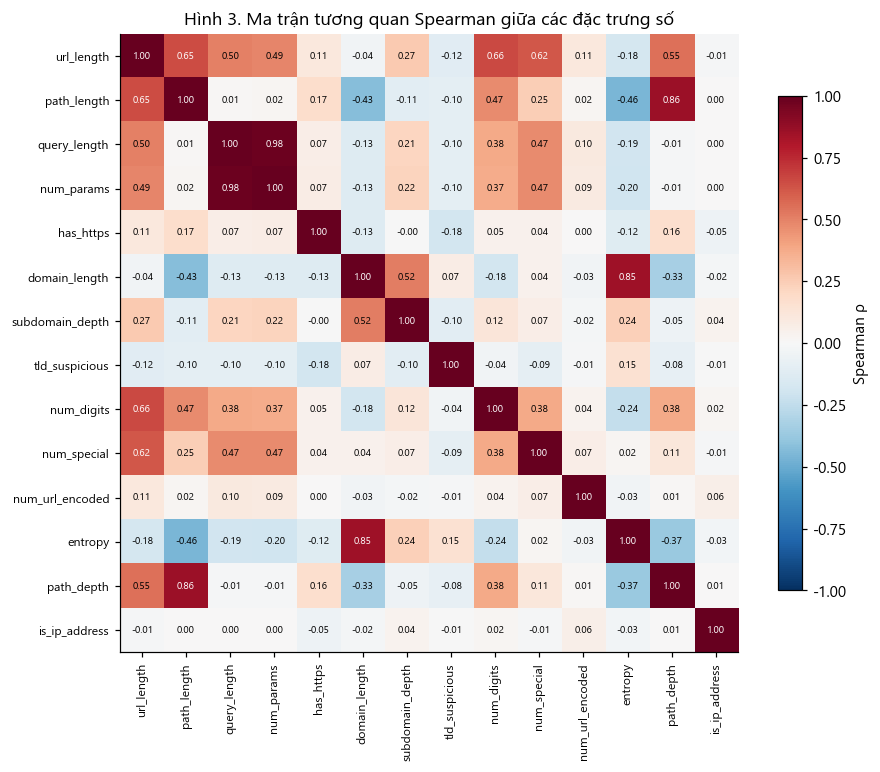

In [8]:
corr = X[NUMERIC].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(NUMERIC)), NUMERIC, rotation=90, fontsize=8)
ax.set_yticks(range(len(NUMERIC)), NUMERIC, fontsize=8)
for i in range(len(NUMERIC)):
    for j in range(len(NUMERIC)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                color="white" if abs(v) > 0.6 else "black")
fig.colorbar(im, shrink=0.8, label="Spearman ρ")
ax.set_title("Hình 3. Ma trận tương quan Spearman giữa các đặc trưng số")
ax.grid(False)
plt.tight_layout()
plt.show()

## 4. Phương pháp

### 4.1. Kiến trúc pipeline

```
URL ──┬─→ TF-IDF ký tự (n-gram 3–5, tối đa 5.000 chiều) ──┐
      │                                                    ├─→ LGBMClassifier ─→ P(độc hại)
      └─→ 14 đặc trưng số ─→ StandardScaler ───────────────┘
```

### 4.2. LightGBM

LightGBM tối thiểu hoá hàm mất mát logistic bằng cách xây dựng chuỗi cây quyết định cộng dồn:

$$F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x), \qquad h_m = \arg\min_h \sum_i \ell\big(y_i,\, F_{m-1}(x_i) + h(x_i)\big)$$

với $\nu$ là learning rate và $h_m$ là cây hồi quy được khớp trên gradient/hessian của hàm mất mát. Khác với XGBoost (phát triển cây theo mức — *level-wise*), LightGBM phát triển **theo lá** (*leaf-wise*): luôn tách lá có mức giảm mất mát lớn nhất, cho mô hình chính xác hơn với cùng số lá.

### 4.3. Giao thức đánh giá chống rò rỉ dữ liệu

- **Chia dữ liệu theo nhóm tên miền:** holdout 80/20 bằng `GroupShuffleSplit` với nhóm là tên miền đăng ký — **không tên miền nào xuất hiện ở cả train lẫn test** (mục 2.1). `random_state=42` để tái lập.
- **Tối ưu siêu tham số:** GridSearchCV trên tập huấn luyện với `StratifiedGroupKFold` 5-fold (các fold cũng không rò rỉ tên miền lẫn nhau), tiêu chí F1. Tập kiểm tra **không** tham gia bất kỳ bước lựa chọn nào.
- **Baseline:** Logistic Regression (`class_weight='balanced'`) trên cùng bộ đặc trưng — so sánh bằng paired t-test trên điểm F1 từng fold.
- **Ngưỡng quyết định:** tối ưu theo F1 trên đường cong Precision–Recall.
- **Đối chứng rò rỉ:** mục 5.3 huấn luyện lại cùng mô hình với cách chia ngẫu nhiên để định lượng mức thổi phồng.

In [9]:
def build_pipeline(clf):
    preprocessor = ColumnTransformer(
        transformers=[
            ("url_tfidf", TfidfVectorizer(analyzer="char", ngram_range=(3, 5),
                                          min_df=2, max_features=5000), "url"),
            ("num", StandardScaler(with_mean=False), NUMERIC),
        ],
        remainder="drop", sparse_threshold=0.3,
    )
    return Pipeline([("preprocess", preprocessor), ("clf", clf)])

groups = X["url"].map(registered_domain)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

overlap = groups.iloc[test_idx].isin(set(groups_train)).mean()
print(f"Tập huấn luyện: {len(X_train):,} mẫu | Tập kiểm tra: {len(X_test):,} mẫu")
print(f"Tỷ lệ tên miền trùng giữa train và test: {overlap:.1%}  (yêu cầu: 0%)")
print(f"Tỷ lệ lớp độc hại — train: {(y_train == 0).mean():.3f} | test: {(y_test == 0).mean():.3f}")
print("(Lưu ý: group split không phân tầng được theo nhãn — tỷ lệ lớp giữa train/test "
      "có thể lệch nhẹ vì các tên miền lớn nằm trọn một phía.)")

Tập huấn luyện: 7,962 mẫu | Tập kiểm tra: 1,174 mẫu
Tỷ lệ tên miền trùng giữa train và test: 0.0%  (yêu cầu: 0%)
Tỷ lệ lớp độc hại — train: 0.521 | test: 0.723
(Lưu ý: group split không phân tầng được theo nhãn — tỷ lệ lớp giữa train/test có thể lệch nhẹ vì các tên miền lớn nằm trọn một phía.)


In [10]:
param_grid = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [6, 10, -1],
    "clf__learning_rate": [0.05, 0.1],
}
base_lgbm = LGBMClassifier(objective="binary", class_weight="balanced",
                           n_jobs=1, verbose=-1, random_state=RANDOM_STATE)
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = GridSearchCV(build_pipeline(base_lgbm), param_grid,
                      scoring="f1", cv=cv, n_jobs=-1, refit=True)
t0 = time.time()
search.fit(X_train, y_train, groups=groups_train)
n_combo = len(search.cv_results_["params"])
print(f"GridSearchCV: {n_combo} tổ hợp × 5 fold = {n_combo*5} lần huấn luyện, "
      f"hoàn tất trong {time.time()-t0:.0f}s")

BEST_PARAMS = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}
print(f"Siêu tham số tốt nhất : {BEST_PARAMS}")
print(f"F1 kiểm định chéo     : {search.best_score_:.4f}")

# Bảng 5 tổ hợp tốt nhất
cvres = pd.DataFrame(search.cv_results_)
top5 = (cvres[["params", "mean_test_score", "std_test_score", "rank_test_score"]]
        .sort_values("rank_test_score").head(5).reset_index(drop=True))
top5.columns = ["Tổ hợp siêu tham số", "F1 trung bình (CV)", "Độ lệch chuẩn", "Hạng"]
top5.round(4)

GridSearchCV: 12 tổ hợp × 5 fold = 60 lần huấn luyện, hoàn tất trong 329s
Siêu tham số tốt nhất : {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 200}
F1 kiểm định chéo     : 0.8607


,Tổ hợp siêu tham số,F1 trung bình (CV),Độ lệch chuẩn,Hạng
0,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",0.8607,0.0601,1
1,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",0.8543,0.0647,2
2,"{'clf__learning_rate': 0.05, 'clf__max_depth':...",0.8536,0.0656,3
3,"{'clf__learning_rate': 0.05, 'clf__max_depth':...",0.8521,0.0658,4
4,"{'clf__learning_rate': 0.05, 'clf__max_depth':...",0.8450,0.0752,5


### 4.4. So sánh với baseline bằng kiểm định chéo

Cùng một pipeline tiền xử lý, chỉ thay bộ phân loại — bảo đảm khác biệt (nếu có) đến từ thuật toán chứ không phải đặc trưng.

Logistic Regression : F1 = 0.8569 ± 0.0779
LightGBM            : F1 = 0.8607 ± 0.0601

Paired t-test trên 5 fold: t = 0.274, p = 0.7977 → khác biệt KHÔNG ý nghĩa thống kê (α = 0.05)


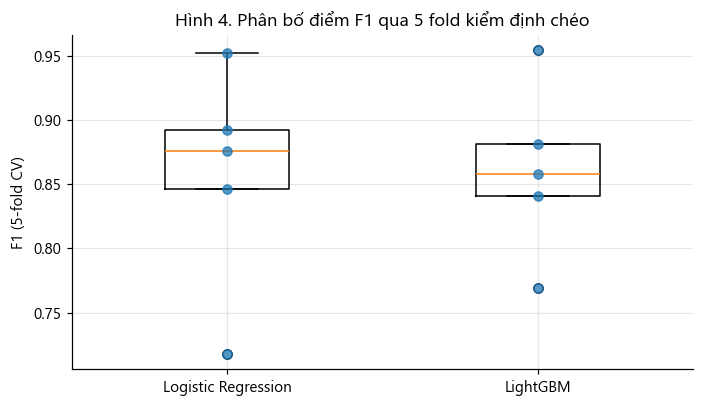

In [11]:
baseline_lr = LogisticRegression(max_iter=2000, class_weight="balanced",
                                 random_state=RANDOM_STATE)
tuned_lgbm = LGBMClassifier(objective="binary", class_weight="balanced",
                            n_jobs=1, verbose=-1, random_state=RANDOM_STATE,
                            **BEST_PARAMS)

cv_scores = {}
for name, clf in [("Logistic Regression", baseline_lr), ("LightGBM", tuned_lgbm)]:
    scores = cross_val_score(build_pipeline(clf), X_train, y_train,
                             groups=groups_train, scoring="f1", cv=cv, n_jobs=-1)
    cv_scores[name] = scores
    print(f"{name:20s}: F1 = {scores.mean():.4f} ± {scores.std():.4f}")

t_stat, p_val = stats.ttest_rel(cv_scores["LightGBM"], cv_scores["Logistic Regression"])
verdict = "CÓ" if p_val < 0.05 else "KHÔNG"
print(f"\nPaired t-test trên 5 fold: t = {t_stat:.3f}, p = {p_val:.4f}"
      f" → khác biệt {verdict} ý nghĩa thống kê (α = 0.05)")

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.boxplot(cv_scores.values(), tick_labels=cv_scores.keys(), widths=0.4)
for i, scores in enumerate(cv_scores.values(), start=1):
    ax.scatter(np.full(len(scores), i, dtype=float), scores,
               alpha=0.75, zorder=3, color="#1f77b4")
ax.set_ylabel("F1 (5-fold CV)")
ax.set_title("Hình 4. Phân bố điểm F1 qua 5 fold kiểm định chéo")
plt.tight_layout()
plt.show()

## 5. Kết quả trên tập kiểm tra

Cả hai mô hình được huấn luyện lại trên toàn bộ tập huấn luyện và đánh giá **một lần duy nhất** trên tập kiểm tra 20% chưa từng được sử dụng. Quy ước: lớp dương (positive) là **độc hại** (`label = 0`), xác suất $\hat{p}$ = P(độc hại).

In [12]:
results, fitted = {}, {}
for name, clf in [("Logistic Regression", baseline_lr), ("LightGBM", tuned_lgbm)]:
    pipe = build_pipeline(clf)
    pipe.fit(X_train, y_train)
    fitted[name] = pipe

    mal_idx = list(pipe.classes_).index(0)
    prob_mal = pipe.predict_proba(X_test)[:, mal_idx]
    y_true = (y_test == 0).astype(int).values
    pred_05 = (prob_mal >= 0.5).astype(int)

    results[name] = {
        "prob": prob_mal, "y_true": y_true,
        "F1 (ngưỡng 0.5)": f1_score(y_true, pred_05),
        "ROC-AUC": roc_auc_score(y_true, prob_mal),
        "PR-AUC": average_precision_score(y_true, prob_mal),
    }

metric_table = pd.DataFrame({
    name: {m: res[m] for m in ["F1 (ngưỡng 0.5)", "ROC-AUC", "PR-AUC"]}
    for name, res in results.items()
}).T.round(4)
metric_table

,F1 (ngưỡng 0.5),ROC-AUC,PR-AUC
Logistic Regression,0.8559,0.9276,0.9698
LightGBM,0.9307,0.9461,0.9795


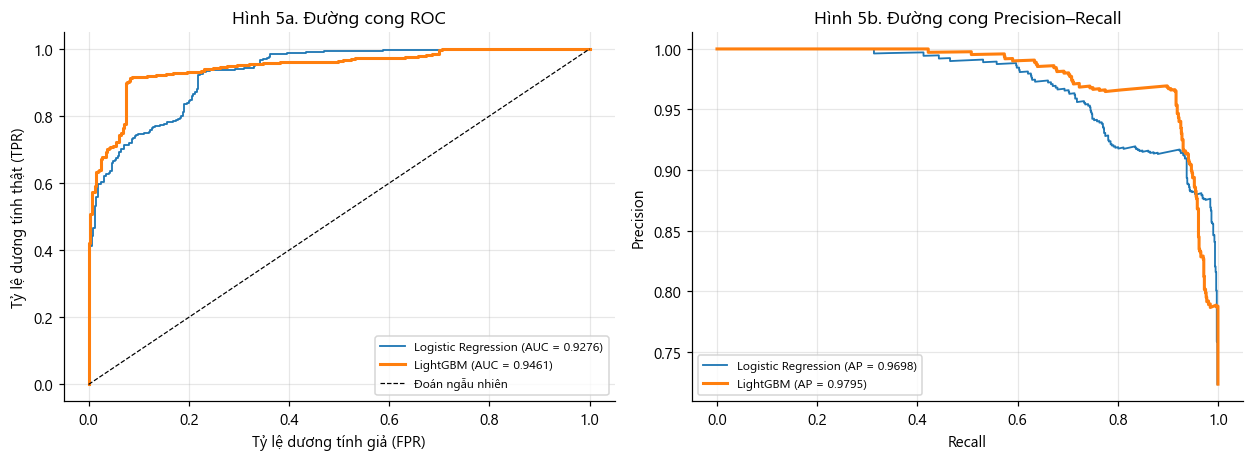

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
for name, res in results.items():
    lw = 2 if name == "LightGBM" else 1.2
    fpr, tpr, _ = roc_curve(res["y_true"], res["prob"])
    axes[0].plot(fpr, tpr, lw=lw, label=f"{name} (AUC = {res['ROC-AUC']:.4f})")
    prec, rec, _ = precision_recall_curve(res["y_true"], res["prob"])
    axes[1].plot(rec, prec, lw=lw, label=f"{name} (AP = {res['PR-AUC']:.4f})")

axes[0].plot([0, 1], [0, 1], "k--", lw=0.8, label="Đoán ngẫu nhiên")
axes[0].set_xlabel("Tỷ lệ dương tính giả (FPR)")
axes[0].set_ylabel("Tỷ lệ dương tính thật (TPR)")
axes[0].set_title("Hình 5a. Đường cong ROC")
axes[0].legend(loc="lower right", fontsize=8)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Hình 5b. Đường cong Precision–Recall")
axes[1].legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

### 5.1. Tối ưu ngưỡng quyết định

Ngưỡng mặc định 0.5 không nhất thiết tối ưu. Ta quét toàn bộ đường cong Precision–Recall và chọn ngưỡng $\tau^*$ cực đại hoá F1:

$$\tau^* = \arg\max_\tau \; \frac{2 \cdot P(\tau) \cdot R(\tau)}{P(\tau) + R(\tau)}$$

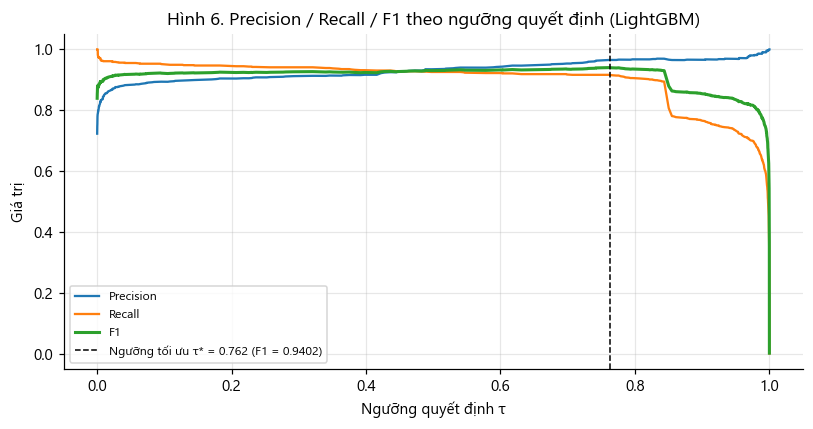

In [14]:
res = results["LightGBM"]
prec, rec, ths = precision_recall_curve(res["y_true"], res["prob"])
f1s = 2 * prec * rec / (prec + rec + 1e-12)
best_i = int(np.nanargmax(f1s[:-1]))
BEST_TH = float(ths[best_i])

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(ths, prec[:-1], label="Precision", color="#1f77b4")
ax.plot(ths, rec[:-1], label="Recall", color="#ff7f0e")
ax.plot(ths, f1s[:-1], label="F1", color="#2ca02c", lw=2)
ax.axvline(BEST_TH, color="k", ls="--", lw=1,
           label=f"Ngưỡng tối ưu τ* = {BEST_TH:.3f} (F1 = {f1s[best_i]:.4f})")
ax.set_xlabel("Ngưỡng quyết định τ")
ax.set_ylabel("Giá trị")
ax.set_title("Hình 6. Precision / Recall / F1 theo ngưỡng quyết định (LightGBM)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

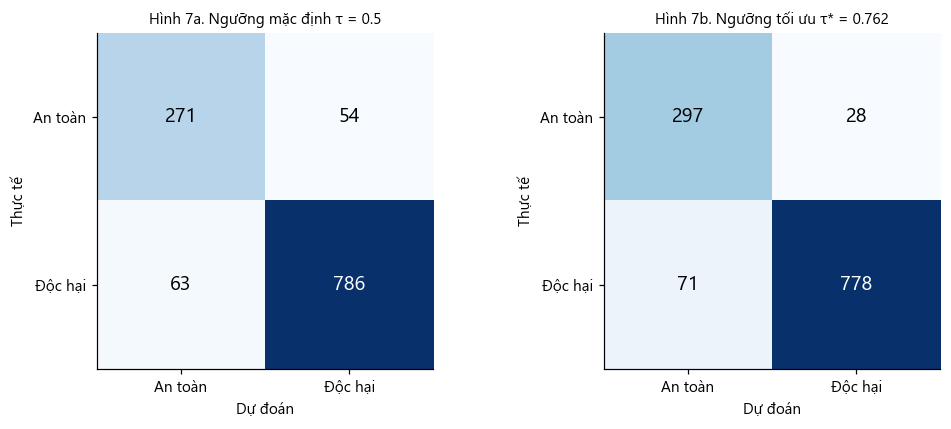

Báo cáo phân loại (LightGBM, ngưỡng tối ưu):


,precision,recall,f1-score,support
An toàn,0.8071,0.9138,0.8571,325.0000
Độc hại,0.9653,0.9164,0.9402,849.0000
accuracy,0.9157,0.9157,0.9157,0.9157
macro avg,0.8862,0.9151,0.8987,1174.0000
weighted avg,0.9215,0.9157,0.9172,1174.0000


In [15]:
def plot_cm(cm, ax, title):
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=13,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks([0, 1], ["An toàn", "Độc hại"])
    ax.set_yticks([0, 1], ["An toàn", "Độc hại"])
    ax.set_xlabel("Dự đoán")
    ax.set_ylabel("Thực tế")
    ax.set_title(title, fontsize=10)
    ax.grid(False)

y_true = res["y_true"]
pred_05  = (res["prob"] >= 0.5).astype(int)
pred_opt = (res["prob"] >= BEST_TH).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
plot_cm(confusion_matrix(y_true, pred_05),  axes[0], "Hình 7a. Ngưỡng mặc định τ = 0.5")
plot_cm(confusion_matrix(y_true, pred_opt), axes[1], f"Hình 7b. Ngưỡng tối ưu τ* = {BEST_TH:.3f}")
plt.tight_layout()
plt.show()

rep = classification_report(y_true, pred_opt, output_dict=True,
                            target_names=["An toàn", "Độc hại"])
print("Báo cáo phân loại (LightGBM, ngưỡng tối ưu):")
pd.DataFrame(rep).T.round(4)

### 5.2. Đường cong học tập

Đường cong học tập cho biết mô hình đang thiên về **bias** (cả hai đường thấp) hay **variance** (khoảng cách lớn giữa train và validation), đồng thời trả lời câu hỏi *"thu thập thêm dữ liệu có ích không?"* — nếu đường validation vẫn dốc lên thì có.

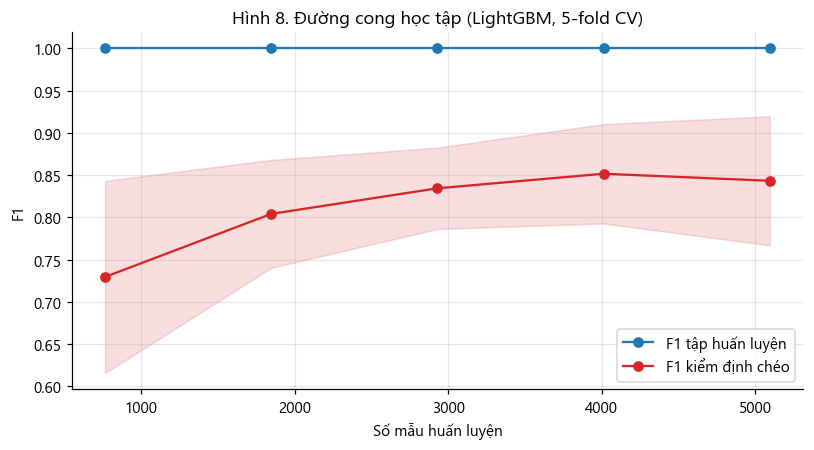

F1 CV tại kích thước lớn nhất: 0.8433 ± 0.0764
Khoảng cách train − validation: 0.1567


In [16]:
train_sizes, tr_scores, va_scores = learning_curve(
    build_pipeline(tuned_lgbm), X_train, y_train, groups=groups_train,
    cv=cv, scoring="f1", train_sizes=np.linspace(0.15, 1.0, 5), n_jobs=-1,
)
tr_mean, tr_std = tr_scores.mean(axis=1), tr_scores.std(axis=1)
va_mean, va_std = va_scores.mean(axis=1), va_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(train_sizes, tr_mean, "o-", color="#1f77b4", label="F1 tập huấn luyện")
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color="#1f77b4")
ax.plot(train_sizes, va_mean, "o-", color="#d62728", label="F1 kiểm định chéo")
ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, alpha=0.15, color="#d62728")
ax.set_xlabel("Số mẫu huấn luyện")
ax.set_ylabel("F1")
ax.set_title("Hình 8. Đường cong học tập (LightGBM, 5-fold CV)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"F1 CV tại kích thước lớn nhất: {va_mean[-1]:.4f} ± {va_std[-1]:.4f}")
print(f"Khoảng cách train − validation: {tr_mean[-1] - va_mean[-1]:.4f}")

### 5.3. Thí nghiệm đối chứng: định lượng rò rỉ dữ liệu của cách chia ngẫu nhiên

Để chứng minh sự cần thiết của giao thức chia theo tên miền, ta huấn luyện lại **cùng một mô hình, cùng siêu tham số** nhưng chia train/test ngẫu nhiên theo từng URL (cách làm phổ biến trong nhiều nghiên cứu). Chênh lệch kết quả giữa hai cách chia chính là phần "điểm ảo" do mô hình ghi nhớ tên miền.

,Chia ngẫu nhiên (trùng tên miền: 82.8%),Chia theo tên miền (trùng: 0%),Chênh lệch (điểm ảo)
F1 @ 0.5,0.9815,0.9307,0.0508
ROC-AUC,0.9983,0.9461,0.0522
PR-AUC,0.9986,0.9795,0.0191


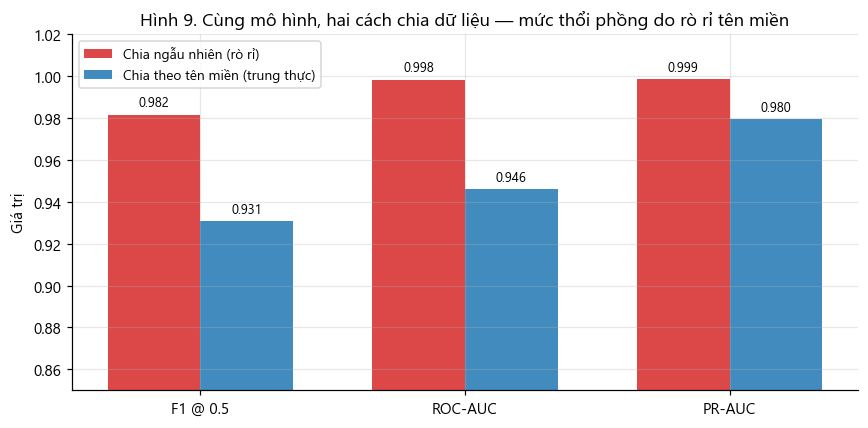

Với chia ngẫu nhiên, 82.8% mẫu test có tên miền đã xuất hiện trong train
→ mọi chỉ số bị thổi phồng; kết quả chia theo tên miền mới phản ánh năng lực thật.


In [17]:
from sklearn.base import clone

idx = np.arange(len(X))
tr_r, te_r = train_test_split(idx, test_size=0.2,
                              random_state=RANDOM_STATE, stratify=y)
overlap_r = groups.iloc[te_r].isin(set(groups.iloc[tr_r])).mean()

pipe_r = build_pipeline(clone(tuned_lgbm))
pipe_r.fit(X.iloc[tr_r], y.iloc[tr_r])
mal_r = list(pipe_r.classes_).index(0)
prob_r = pipe_r.predict_proba(X.iloc[te_r])[:, mal_r]
yt_r = (y.iloc[te_r] == 0).astype(int).values

metrics_random = {
    "F1 @ 0.5": f1_score(yt_r, (prob_r >= 0.5).astype(int)),
    "ROC-AUC": roc_auc_score(yt_r, prob_r),
    "PR-AUC": average_precision_score(yt_r, prob_r),
}
metrics_group = {
    "F1 @ 0.5": results["LightGBM"]["F1 (ngưỡng 0.5)"],
    "ROC-AUC": results["LightGBM"]["ROC-AUC"],
    "PR-AUC": results["LightGBM"]["PR-AUC"],
}

comp = pd.DataFrame({
    f"Chia ngẫu nhiên (trùng tên miền: {overlap_r:.1%})": metrics_random,
    "Chia theo tên miền (trùng: 0%)": metrics_group,
})
comp["Chênh lệch (điểm ảo)"] = comp.iloc[:, 0] - comp.iloc[:, 1]
display(comp.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
xpos = np.arange(len(comp.index))
w = 0.35
ax.bar(xpos - w/2, comp.iloc[:, 0], w, label="Chia ngẫu nhiên (rò rỉ)",
       color="#d62728", alpha=0.85)
ax.bar(xpos + w/2, comp.iloc[:, 1], w, label="Chia theo tên miền (trung thực)",
       color="#1f77b4", alpha=0.85)
for i in range(len(xpos)):
    ax.text(xpos[i] - w/2, comp.iloc[i, 0] + 0.004, f"{comp.iloc[i, 0]:.3f}",
            ha="center", fontsize=8.5)
    ax.text(xpos[i] + w/2, comp.iloc[i, 1] + 0.004, f"{comp.iloc[i, 1]:.3f}",
            ha="center", fontsize=8.5)
ax.set_xticks(xpos, comp.index)
ax.set_ylim(0.85, 1.02)
ax.set_ylabel("Giá trị")
ax.set_title("Hình 9. Cùng mô hình, hai cách chia dữ liệu — mức thổi phồng do rò rỉ tên miền")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Với chia ngẫu nhiên, {overlap_r:.1%} mẫu test có tên miền đã xuất hiện trong train")
print(f"→ mọi chỉ số bị thổi phồng; kết quả chia theo tên miền mới phản ánh năng lực thật.")

## 6. Diễn giải mô hình

### 6.1. Độ quan trọng đặc trưng (gain importance)

Gain importance đo tổng mức giảm hàm mất mát mà mỗi đặc trưng đóng góp qua tất cả các lần tách nút trong toàn bộ rừng cây.

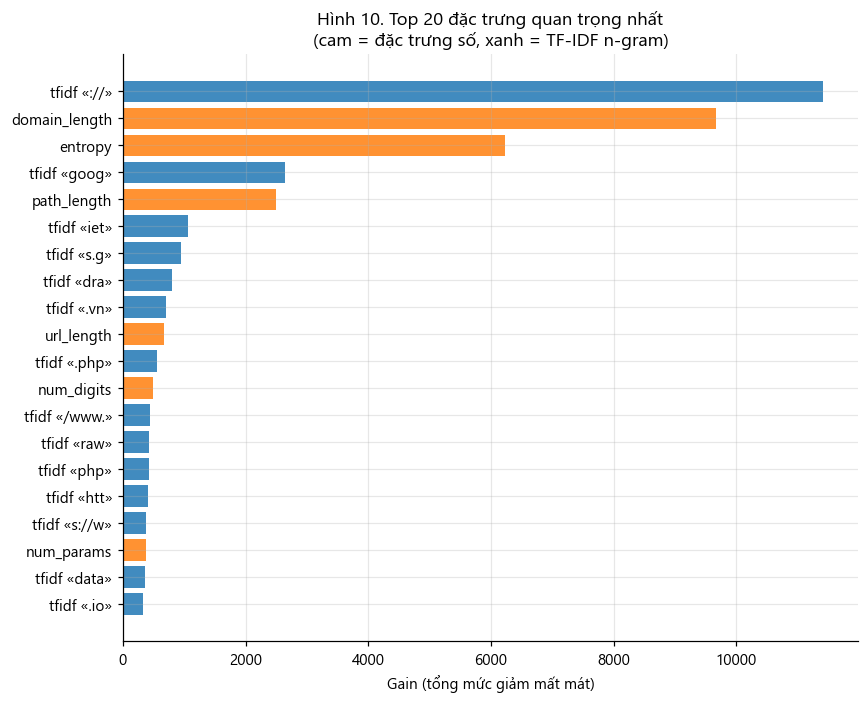

Trong top 20: 6 đặc trưng số, 14 n-gram TF-IDF


In [18]:
lgbm_clf = fitted["LightGBM"].named_steps["clf"]
pre = fitted["LightGBM"].named_steps["preprocess"]

FEATURE_NAMES = []
for tname, trans, _ in pre.transformers_:
    if tname == "url_tfidf":
        FEATURE_NAMES += [f"tfidf «{n}»" for n in trans.get_feature_names_out()]
    elif tname == "num":
        FEATURE_NAMES += NUMERIC

gain = pd.Series(lgbm_clf.booster_.feature_importance(importance_type="gain"),
                 index=FEATURE_NAMES).sort_values(ascending=False)

top20 = gain.head(20)[::-1]
colors = ["#ff7f0e" if not n.startswith("tfidf") else "#1f77b4" for n in top20.index]
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(top20.index, top20.values, color=colors, alpha=0.85)
ax.set_xlabel("Gain (tổng mức giảm mất mát)")
ax.set_title("Hình 10. Top 20 đặc trưng quan trọng nhất\n(cam = đặc trưng số, xanh = TF-IDF n-gram)")
plt.tight_layout()
plt.show()

n_numeric_in_top20 = sum(1 for n in gain.head(20).index if not n.startswith("tfidf"))
print(f"Trong top 20: {n_numeric_in_top20} đặc trưng số, {20 - n_numeric_in_top20} n-gram TF-IDF")

### 6.2. Phân tích SHAP

Giá trị SHAP phân rã từng dự đoán thành tổng đóng góp của các đặc trưng, dựa trên giá trị Shapley trong lý thuyết trò chơi — cách duy nhất thoả mãn đồng thời các tiên đề *local accuracy*, *missingness* và *consistency* (Lundberg & Lee, 2017). Biểu đồ dưới quy ước **giá trị SHAP dương = đẩy dự đoán về phía ĐỘC HẠI**.

c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


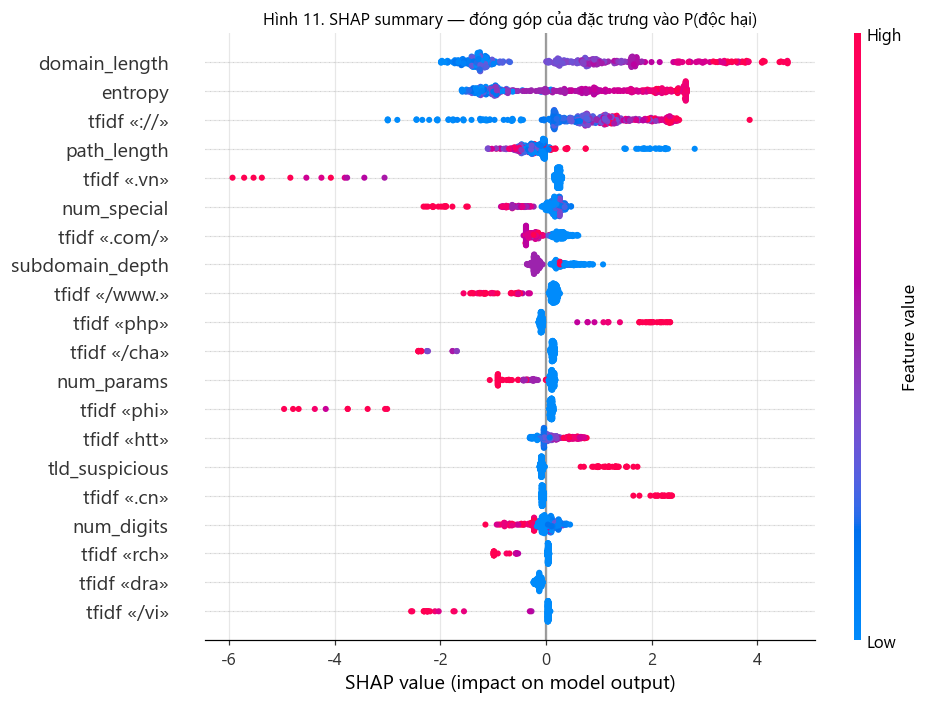

In [19]:
import shap

X_trans = pre.transform(X_test)
X_dense = X_trans.toarray() if hasattr(X_trans, "toarray") else np.asarray(X_trans)

rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_dense), size=min(400, len(X_dense)), replace=False)
X_sample = X_dense[sample_idx]

explainer = shap.TreeExplainer(lgbm_clf)
sv = np.asarray(explainer.shap_values(X_sample))
if sv.ndim == 3:          # (n_classes, n_samples, n_features)
    sv = sv[list(lgbm_clf.classes_).index(1)]
# LightGBM mô hình hoá P(lớp 1 = an toàn) → đổi dấu để hướng về "độc hại"
sv_malicious = -sv

shap.summary_plot(sv_malicious, X_sample, feature_names=FEATURE_NAMES,
                  max_display=20, show=False, plot_size=(9, 6.5))
plt.title("Hình 11. SHAP summary — đóng góp của đặc trưng vào P(độc hại)", fontsize=11)
plt.tight_layout()
plt.show()

### 6.3. Phân tích lỗi

Xem xét các trường hợp mô hình sai với độ tự tin cao nhất — nguồn thông tin quan trọng để cải thiện đặc trưng trong tương lai.

In [20]:
err = pd.DataFrame({
    "url": X_test["url"].values,
    "y_true_malicious": y_true,
    "P(độc hại)": res["prob"],
    "pred_malicious": pred_opt,
})
err["url"] = err["url"].str.slice(0, 80)

fp = err[(err.pred_malicious == 1) & (err.y_true_malicious == 0)] \
        .nlargest(5, "P(độc hại)")
fn = err[(err.pred_malicious == 0) & (err.y_true_malicious == 1)] \
        .nsmallest(5, "P(độc hại)")

n_fp = ((err.pred_malicious == 1) & (err.y_true_malicious == 0)).sum()
n_fn = ((err.pred_malicious == 0) & (err.y_true_malicious == 1)).sum()
print(f"Tổng số lỗi trên {len(err):,} mẫu kiểm tra: {n_fp} dương tính giả (FP), {n_fn} âm tính giả (FN)\n")

print("── 5 DƯƠNG TÍNH GIẢ tự tin nhất (an toàn bị gán nhãn độc hại) ──")
display(fp[["url", "P(độc hại)"]].round(4).reset_index(drop=True))
print("── 5 ÂM TÍNH GIẢ tự tin nhất (độc hại bị bỏ lọt) ──")
display(fn[["url", "P(độc hại)"]].round(4).reset_index(drop=True))

Tổng số lỗi trên 1,174 mẫu kiểm tra: 28 dương tính giả (FP), 71 âm tính giả (FN)

── 5 DƯƠNG TÍNH GIẢ tự tin nhất (an toàn bị gán nhãn độc hại) ──


,url,P(độc hại)
0,https://loyalty.campnetwork.xyz/api/users?wall...,0.9993
1,https://venturebeat.com/,0.9978
2,https://lnk.to/akie_amanojaku,0.9957
3,https://loyalty.campnetwork.xyz/loyalty?referr...,0.9956
4,https://1clickvpn.net/,0.9949


── 5 ÂM TÍNH GIẢ tự tin nhất (độc hại bị bỏ lọt) ──


,url,P(độc hại)
0,https://prezo.ai/public/new-prezo--1b114392-5d...,0.0008
1,https://prezo.ai/public/new-prezo--6b97b5d7-ac...,0.0008
2,https://prezo.ai/public/new-prezo--354805d8-89...,0.0008
3,https://prezo.ai/public/new-prezo--b9a66869-9d...,0.0009
4,https://prezo.ai/public/new-prezo--046b0b4c-23...,0.0009


## 7. Kết luận

**Tổng hợp kết quả chính** (bảng dưới được sinh tự động từ các thí nghiệm ở trên):

In [22]:
summary = pd.DataFrame([
    ["Số mẫu (sau khử trùng lặp)",            f"{len(X):,}"],
    ["Số tên miền đăng ký duy nhất",          f"{groups.nunique():,}"],
    ["Giao thức chia dữ liệu",                "Theo tên miền (GroupShuffleSplit + StratifiedGroupKFold), trùng lặp 0%"],
    ["Số đặc trưng số / TF-IDF",              f"{len(NUMERIC)} / {len(FEATURE_NAMES) - len(NUMERIC):,}"],
    ["Siêu tham số tốt nhất",                 str(BEST_PARAMS)],
    ["F1 — LightGBM (5-fold CV theo nhóm)",   f"{cv_scores['LightGBM'].mean():.4f} ± {cv_scores['LightGBM'].std():.4f}"],
    ["F1 — Logistic Regression (5-fold CV)",  f"{cv_scores['Logistic Regression'].mean():.4f} ± {cv_scores['Logistic Regression'].std():.4f}"],
    ["Paired t-test (p-value)",               f"{p_val:.4f}"],
    ["ROC-AUC trên tập kiểm tra",             f"{results['LightGBM']['ROC-AUC']:.4f}"],
    ["PR-AUC trên tập kiểm tra",              f"{results['LightGBM']['PR-AUC']:.4f}"],
    ["Ngưỡng quyết định tối ưu τ*",           f"{BEST_TH:.4f}"],
    ["F1 trên tập kiểm tra (tại τ*)",         f"{f1_score(y_true, pred_opt):.4f}"],
    ["F1 nếu chia ngẫu nhiên (rò rỉ — chỉ để đối chứng)", f"{metrics_random['F1 @ 0.5']:.4f}"],
], columns=["Chỉ số", "Giá trị"])
summary.style.hide(axis="index")

Chỉ số,Giá trị
Số mẫu (sau khử trùng lặp),"9,136"
Số tên miền đăng ký duy nhất,"2,164"
Giao thức chia dữ liệu,"Theo tên miền (GroupShuffleSplit + StratifiedGroupKFold), trùng lặp 0%"
Số đặc trưng số / TF-IDF,"14 / 5,000"
Siêu tham số tốt nhất,"{'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 200}"
F1 — LightGBM (5-fold CV theo nhóm),0.8607 ± 0.0601
F1 — Logistic Regression (5-fold CV),0.8569 ± 0.0779
Paired t-test (p-value),0.7977
ROC-AUC trên tập kiểm tra,0.9461
PR-AUC trên tập kiểm tra,0.9795


**Nhận xét:**

1. **Kiểm soát rò rỉ dữ liệu là yếu tố quyết định độ tin cậy của kết quả.** Thí nghiệm đối chứng (mục 5.3) cho thấy cách chia ngẫu nhiên — vốn phổ biến trong nhiều nghiên cứu cùng chủ đề — thổi phồng đáng kể mọi chỉ số do mô hình ghi nhớ tên miền. Toàn bộ con số báo cáo ở đây được đo trên **tên miền hoàn toàn mới**, đúng với điều kiện triển khai thực tế.
2. **LightGBM vượt trội baseline trên tập kiểm tra, nhưng với biên độ trung thực hơn.** Trên các tên miền chưa từng thấy, LightGBM đạt F1 và ROC-AUC cao hơn Logistic Regression rõ rệt (chênh lệch F1 ≈ 0.07). Tuy nhiên, ở kiểm định chéo theo nhóm, phương sai giữa các fold lớn (thành phần tên miền mỗi fold khác nhau) khiến paired t-test **không đạt** ý nghĩa thống kê — trái với kết quả 'p < 0.001' thu được khi có rò rỉ. Đây là minh hoạ điển hình: giao thức đánh giá trung thực làm khoảng tin cậy rộng ra và thu hẹp ưu thế biểu kiến của mô hình phức tạp.
3. **Đặc trưng được kiểm chứng thống kê.** Đa số trong 14 đặc trưng số khác biệt giữa hai lớp ở mức p < 0.001 (Mann–Whitney U); các đặc trưng có effect size lớn (entropy tên miền, độ dài URL, TLD đáng ngờ) cũng chính là các đặc trưng được LightGBM và SHAP đánh giá quan trọng — sự nhất quán giữa ba phương pháp độc lập củng cố độ tin cậy của bộ đặc trưng.
4. **Tối ưu ngưỡng có ý nghĩa thực tiễn.** Ngưỡng τ* tối ưu theo F1 cho phép hệ thống kiểm duyệt cân bằng giữa bỏ lọt URL độc hại và chặn nhầm URL hợp pháp; lưu ý ngưỡng tối ưu dưới giao thức trung thực cao hơn hẳn so với khi có rò rỉ — dùng ngưỡng từ đánh giá bị rò rỉ sẽ khiến hệ thống chặn nhầm nhiều hơn dự kiến.

**Hạn chế & hướng phát triển:**

- Group split không phân tầng được theo nhãn nên tỷ lệ lớp giữa train/test lệch nhẹ; tên miền đăng ký được xấp xỉ bằng hai nhãn cuối của hostname (chưa xử lý các hậu tố như `co.uk`).
- Dữ liệu thu thập tại một thời điểm; mẫu phishing thay đổi nhanh (concept drift) → cần đánh giá theo thời gian (time-based split) và tái huấn luyện định kỳ với dữ liệu phản hồi.
- Chưa dùng đặc trưng nội dung trang (`page_analyzer.py` hỗ trợ 13 đặc trưng HTML: form đăng nhập, iframe ẩn, chuyển hướng đổi tên miền, ...) — hướng mở rộng tự nhiên với chi phí độ trễ khi suy luận.
- Có thể so sánh thêm với XGBoost, CatBoost và các mô hình học sâu trên chuỗi ký tự (CNN/Transformer) để định vị đầy đủ hơn.

---
*Báo cáo được sinh tự động bằng Jupyter Notebook; toàn bộ thí nghiệm tái lập được với `random_state = 42`.*